# A two-sector I-HANK model

**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
- 2. [Steady state](#toc2_)    
- 3. [Compute Jacobians](#toc3_)    
- 4. [Foreign demand shock](#toc4_)    
- 5. [Response in consumption to different shocks](#toc5_)    
- 6. [Decomposing consumption response](#toc6_)    
- 7. [Fixed vs floating exchange rate](#toc7_)    
- 8. [Decomposing consumption response under fixed exchange rate](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os #save figures
folder_eu = "EU extension"
os.makedirs(folder_eu, exist_ok=True)

folder_us = "US extension"
os.makedirs(folder_us, exist_ok=True)

import matplotlib.pyplot as plt   
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

from IHANKModel import IHANKModelClass

## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [2]:
model = IHANKModelClass(name='baseline')

In [ ]:
model.info()

In [ ]:
model.draw_DAG(figsize=(15,15),order=['shocks','unknowns','blocks'])

In [3]:
par = model.par
ss = model.ss
path = model.path
sim = model.sim

## 2. <a id='toc2_'></a>[Steady state](#toc0_)

In [ ]:
par.beta_M_dk=0.0
par.beta_M_eu=0.0
par.beta_M_us=0.0

In [4]:
model.find_ss(do_print=True)

household problem in ss solved in 3.0 secs [375 iterations]
household problem in ss simulated in 3.1 secs [419 iterations]
steady state found in 6.6 secs
ss.inc_TH = 0.175
ss.inc_NT = 0.525
par.alphaT = 0.355
par.alphaF = 0.333
par.varphiTH = 1.271
par.varphiNT = 1.271
ss.M_eu_s = 0.056
ss.M_us_s = 0.056
ss.clearing_YTH =   0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.296
ss.NFA = 0.000
ss.CB = 1.000
ss.CB_us = 1.000


In [5]:
model.test_ss()

E              :       1.0000
CB             :       1.0000
E_us           :       1.0000
CB_us          :       1.0000
piM_eu_eu      :       0.0000
piM_us_us      :       0.0000
PM_eu_eu       :       1.0000
PM_us_us       :       1.0000
PM_eu_us       :       1.0000
PM_eu          :       1.0000
PM_us_eu       :       1.0000
PM_us          :       1.0000
PM_dk_eu       :       1.0000
PM_dk_us       :       1.0000
PM_dk          :       1.0000
Z_eu           :       1.0000
i_shock_eu     :       0.0000
Y_eu           :       1.1111
C_eu           :       1.0000
N_eu           :       1.0000
pi_eu          :       0.0000
i_eu           :       0.0050
PF_eu_s        :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.0556
mc_eu          :       1.0000
W_eu           :       1.0000
M_eu           :       0.1111
M_eu_eu        :       0.1000
M_eu_us        :       0.0111
eu_Euler_res   :       0.0000
eu_LS_res      :       0.0000
eu_NKPC_res    :       0.0000
eu_TR_res 

In [ ]:
MPC = np.sum(ss.D[:,:,:-1]*(ss.c[:,:,1:]-ss.c[:,:,:-1])/((1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])))
print(f'{MPC:.2f}')
print(model.par.a_grid.max())

0.32
0.0


In [ ]:
fig = plt.figure(figsize=(18,4),dpi=100)
a_max = 10

# a. consumption
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,1)
ax.set_title(f'consumption')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.c[0,i_z,I],label=f'i_z = {i_z}')

ax.legend(frameon=True)
ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('consumption, $c_t$')

# b. saving
I = par.a_grid < a_max

ax = fig.add_subplot(1,3,2)
ax.set_title(f'saving')

for i_z in [0,par.Nz//2,par.Nz-1]:
    ax.plot(par.a_grid[I],ss.a[0,i_z,I],label=f'i_z = {i_z}')

ax.set_xlabel('savings, $a_{t-1}$')
ax.set_ylabel('savings, $a_{t}$')

fig.tight_layout()
#Saving figure
plt.title("cons_saving.png")
plt.savefig(os.path.join(folder_us, "cons_saving.png"), dpi=300, bbox_inches="tight")


In [ ]:
fig = plt.figure(figsize=(12,4),dpi=100)

# a. income
ax = fig.add_subplot(1,2,1)
ax.set_title('productivity')

y = np.cumsum(np.sum(ss.D[0],axis=1))
ax.plot(par.z_grid,y/y[-1])

ax.set_xlabel('productivity, $z_{t}$')
ax.set_ylabel('CDF')

# b. assets
ax = fig.add_subplot(1,2,2)
ax.set_title('savings')
y = np.insert(np.cumsum(np.sum(ss.D[0],axis=0)),0,0.0)
ax.plot(np.insert(par.a_grid,0,par.a_grid[0]),y/y[-1])
        
ax.set_xlabel('assets, $a_{t}$')
ax.set_ylabel('CDF')
ax.set_xscale('symlog')
#Saving figure
plt.title("prod_saving.png")
plt.savefig(os.path.join(folder_us, "prod_saving.png"), dpi=300, bbox_inches="tight")

## 3. <a id='toc3_'></a>[Compute Jacobians](#toc0_)

**Household transition path:**

note: inputs = steady state value -> expected: constant value (straigt line) in roughly -10^-5 to 10^5

household problem solved along transition path in 0.8 secs
household problem simulated along transition in 4.0 secs



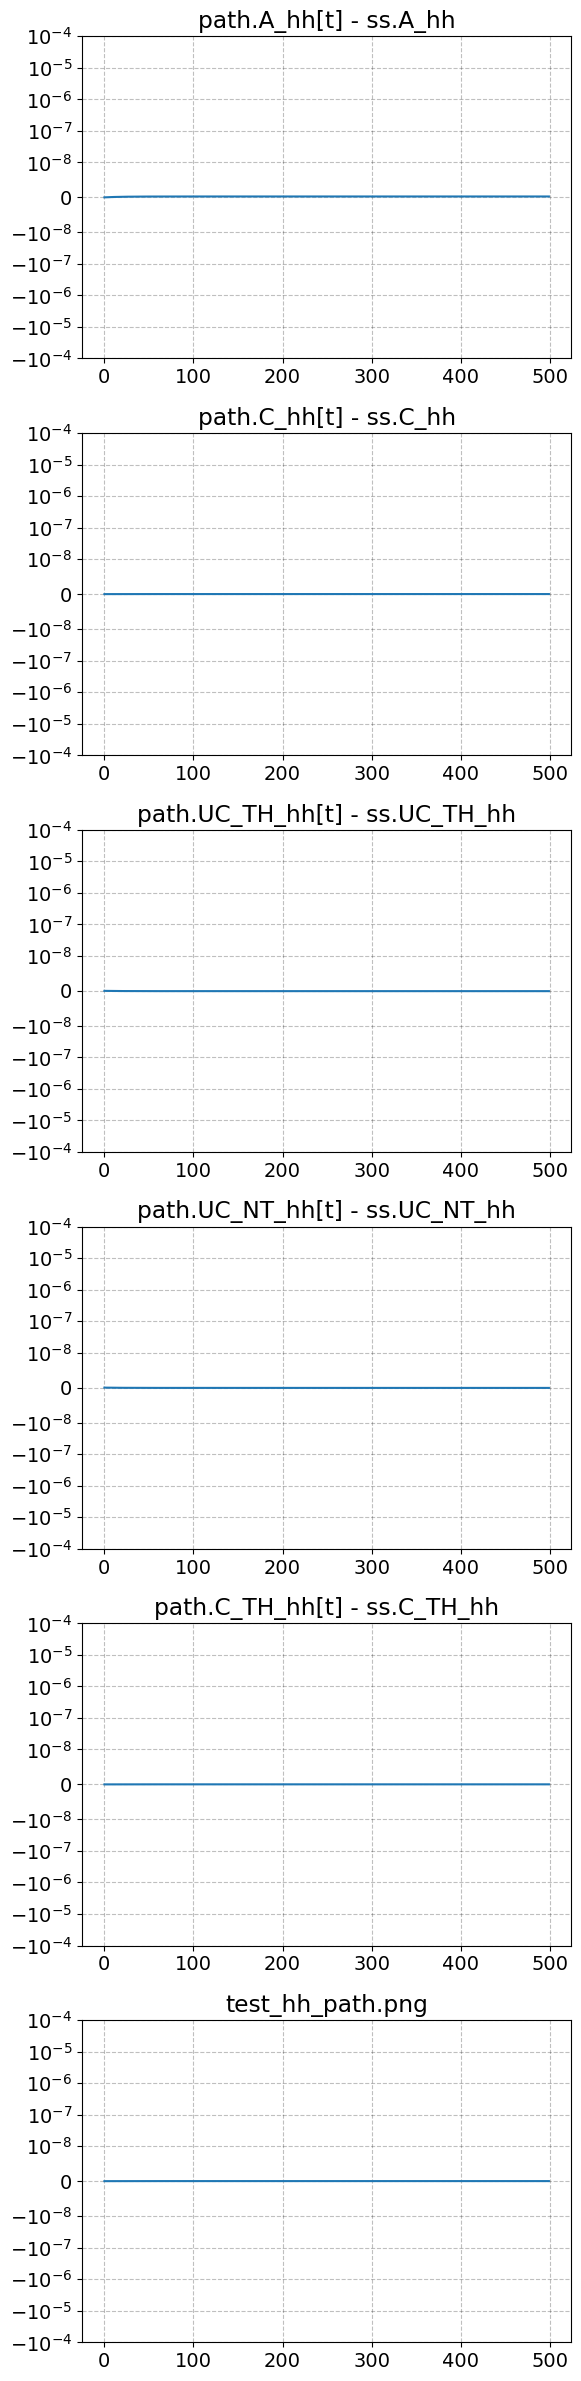

In [7]:
model.test_hh_path()
#Saving figure
plt.title("test_hh_path.png")
plt.savefig(os.path.join(folder_us, "test_hh_path.png"), dpi=300, bbox_inches="tight")

**Full transition path:**

In [ ]:
model.test_path()

**Jacobians:**

In [8]:
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 0.9 secs
curly_Y and curly_D calculated for inc_NT          in 0.7 secs
curly_Y and curly_D calculated for inc_TH          in 0.9 secs
curly_Y and curly_D calculated for ra              in 0.7 secs
curly_E calculated in 3.1 secs
builiding blocks combined in 0.8 secs
household Jacobian computed in 7.1 secs

full Jacobians:
full Jacobian to unknowns computed in 1.0 mins 15 secs [in evaluate_blocks(): 57.0 secs]
full Jacobian to shocks computed in 14.0 secs [in evaluate_blocks(): 5.3 secs]


## 4. <a id='toc4_'></a>[Foreign demand shock](#toc0_)

In [13]:
#par.jump_M_eu_s = -0.0075 # initial jump
#par.rho_M_eu_s = 0.80 # AR(1) coefficeint

#par.jump_rn_eu = -0.00005 # initial jump
#par.rho_rn_eu = 0.80 # AR(1) coefficeint

#par.jump_i_shock_eu = -0.03 # initial jump
#par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

par.jump_i_shock_us = -0.03 # initial jump
par.rho_i_shock_us= 0.80 # AR(1) coefficeint

model.find_transition_path(shocks=['i_shock_us'],do_print=True,do_end_check=True)

print("max |i_shock_eu|:", np.max(np.abs(model.path.i_shock_eu)))
print("max |i_shock|   :", np.max(np.abs(model.path.i_shock)))

finding the transition path:
 it =   0 -> max. abs. error = 3.00e-02
   4.57e-12 in NKWCT_res
   4.57e-12 in NKWCNT_res
   3.47e-12 in clearing_YTH
   9.45e-12 in clearing_YNT
   0.00e+00 in eu_Euler_res
   0.00e+00 in eu_NKPC_res
   0.00e+00 in eu_TR_res
   0.00e+00 in eu_LS_res
   4.16e-17 in eu_RC_res
   0.00e+00 in UIP_res
   0.00e+00 in us_Euler_res
   0.00e+00 in us_NKPC_res
   3.00e-02 in us_TR_res
   0.00e+00 in us_LS_res
   4.16e-17 in us_RC_res
   0.00e+00 in UIP_res_us
 it =   1 -> max. abs. error = 1.45e-02
   1.27e-04 in NKWCT_res
   1.27e-04 in NKWCNT_res
   1.95e-03 in clearing_YTH
   6.45e-04 in clearing_YNT
   1.56e-07 in eu_Euler_res
   9.70e-18 in eu_NKPC_res
   1.13e-17 in eu_TR_res
   2.15e-04 in eu_LS_res
   2.14e-04 in eu_RC_res
   3.41e-04 in UIP_res
   1.88e-04 in us_Euler_res
   6.94e-16 in us_NKPC_res
   3.30e-16 in us_TR_res
   3.97e-03 in us_LS_res
   1.45e-03 in us_RC_res
   1.45e-02 in UIP_res_us
 it =   2 -> max. abs. error = 2.07e-03
   1.77e-05 in NKWC

### shocks ###


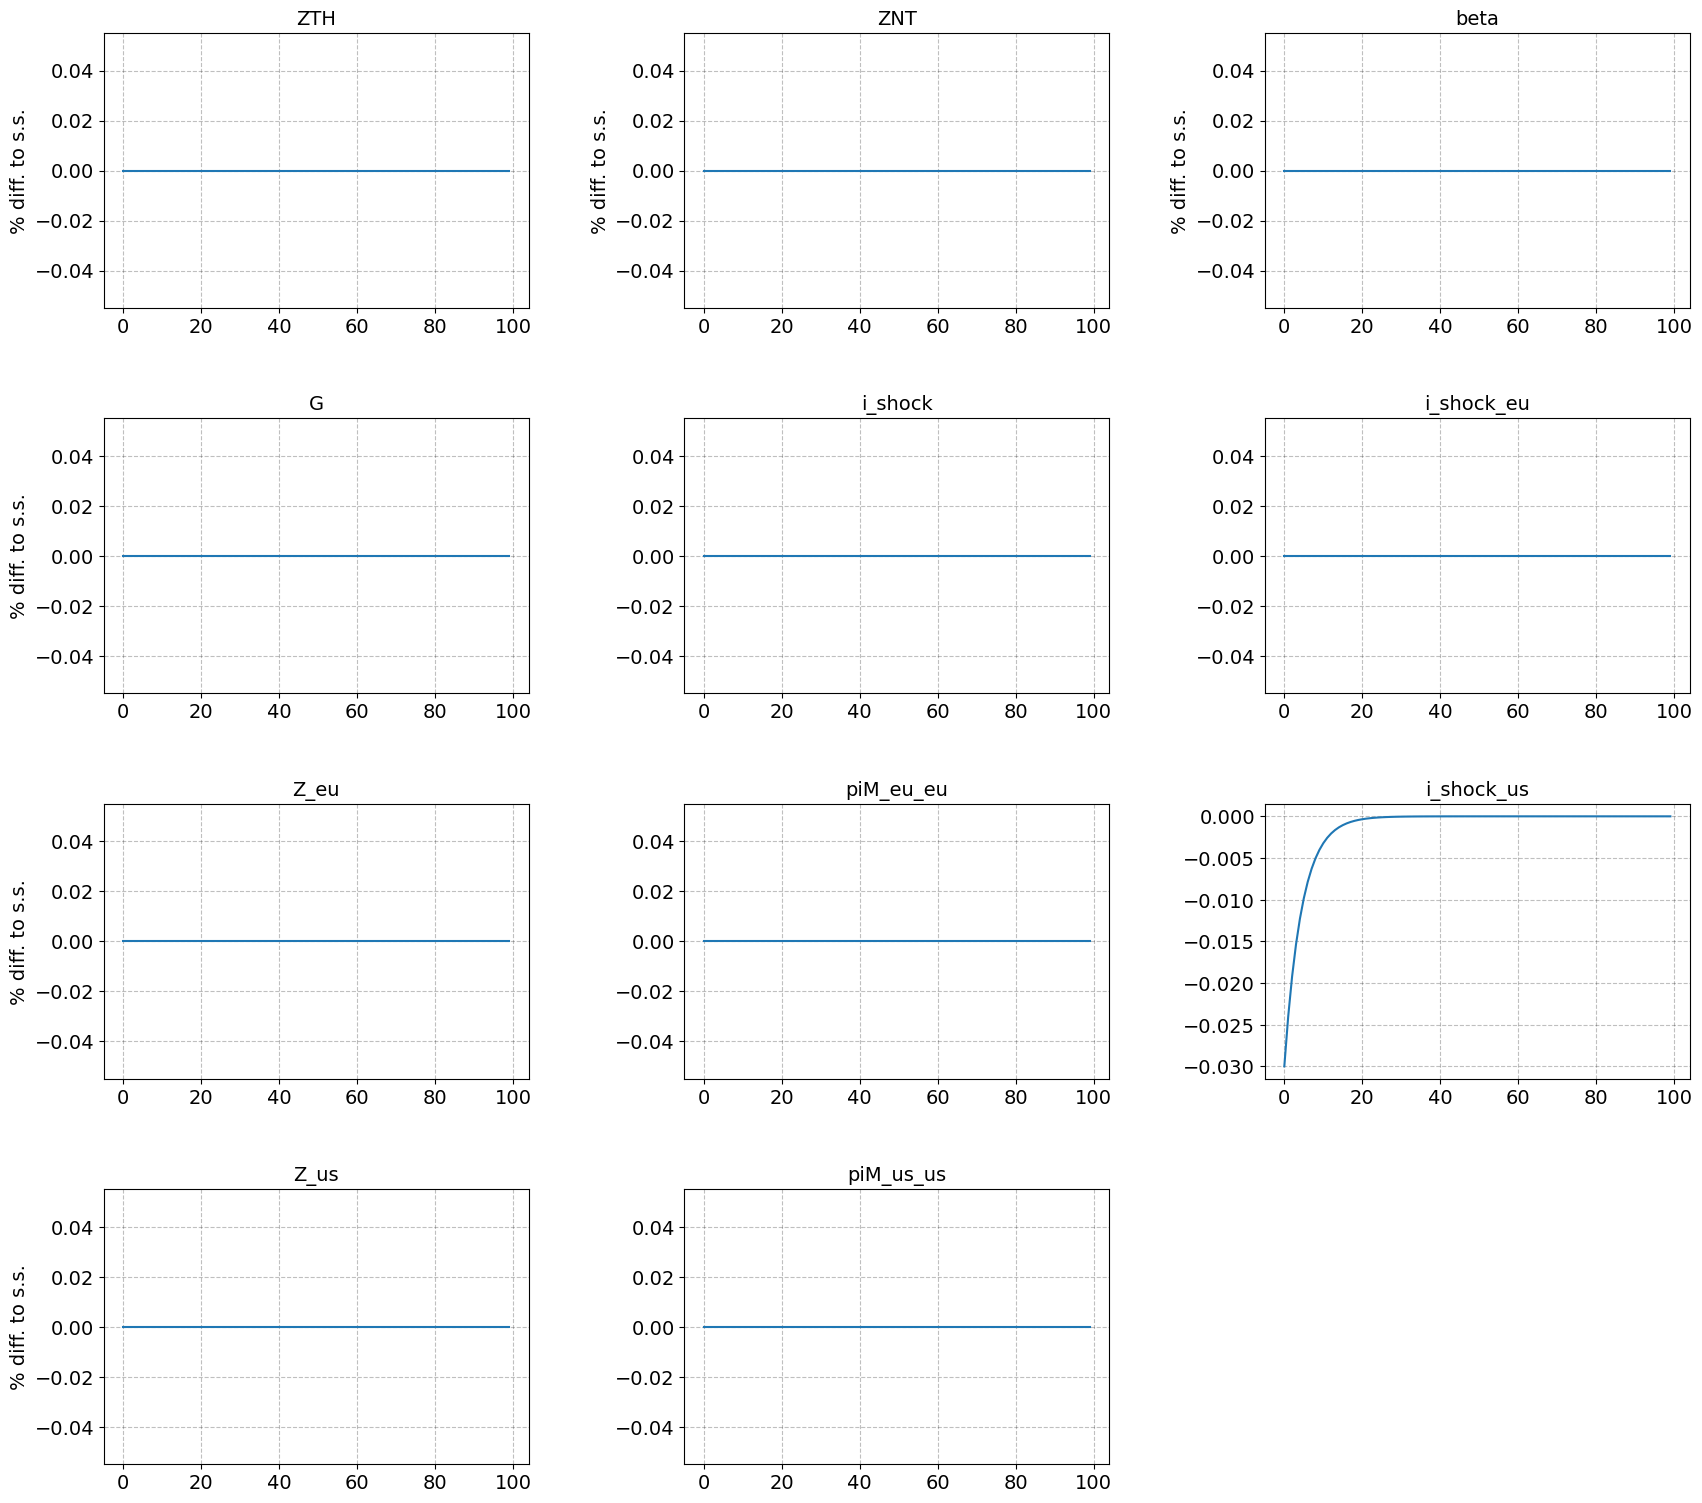


### varnames ###


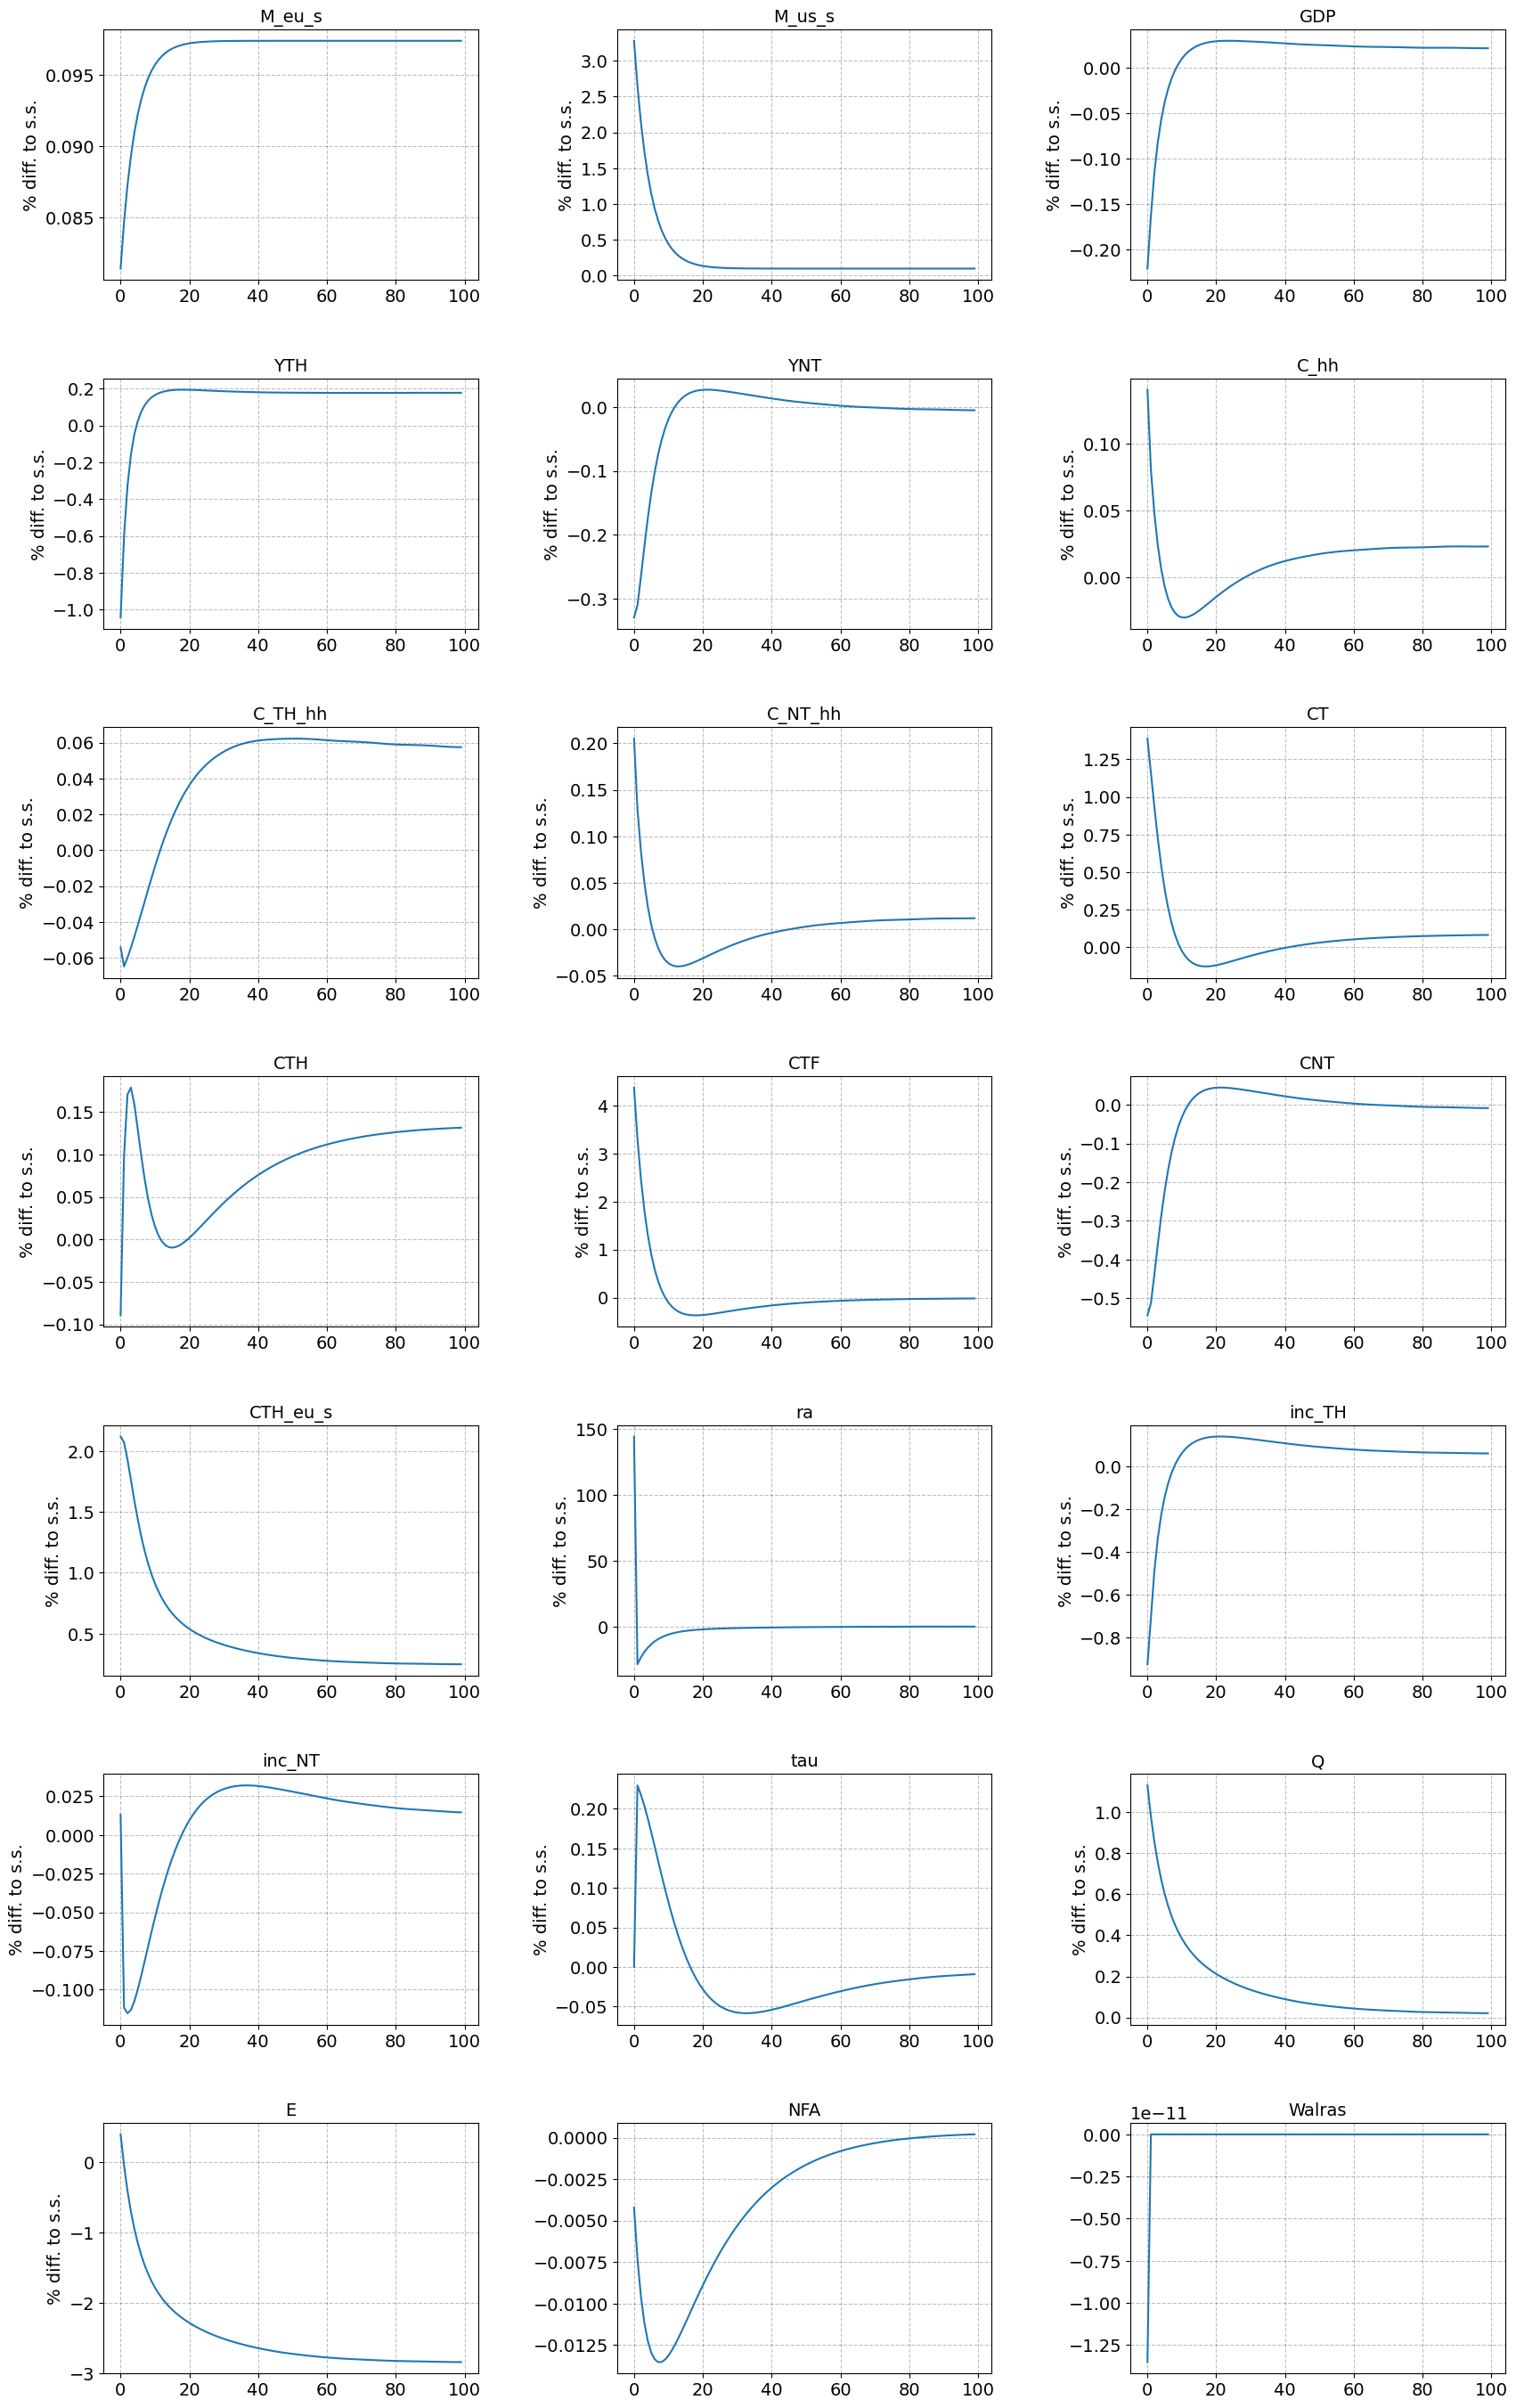


### tagets ###


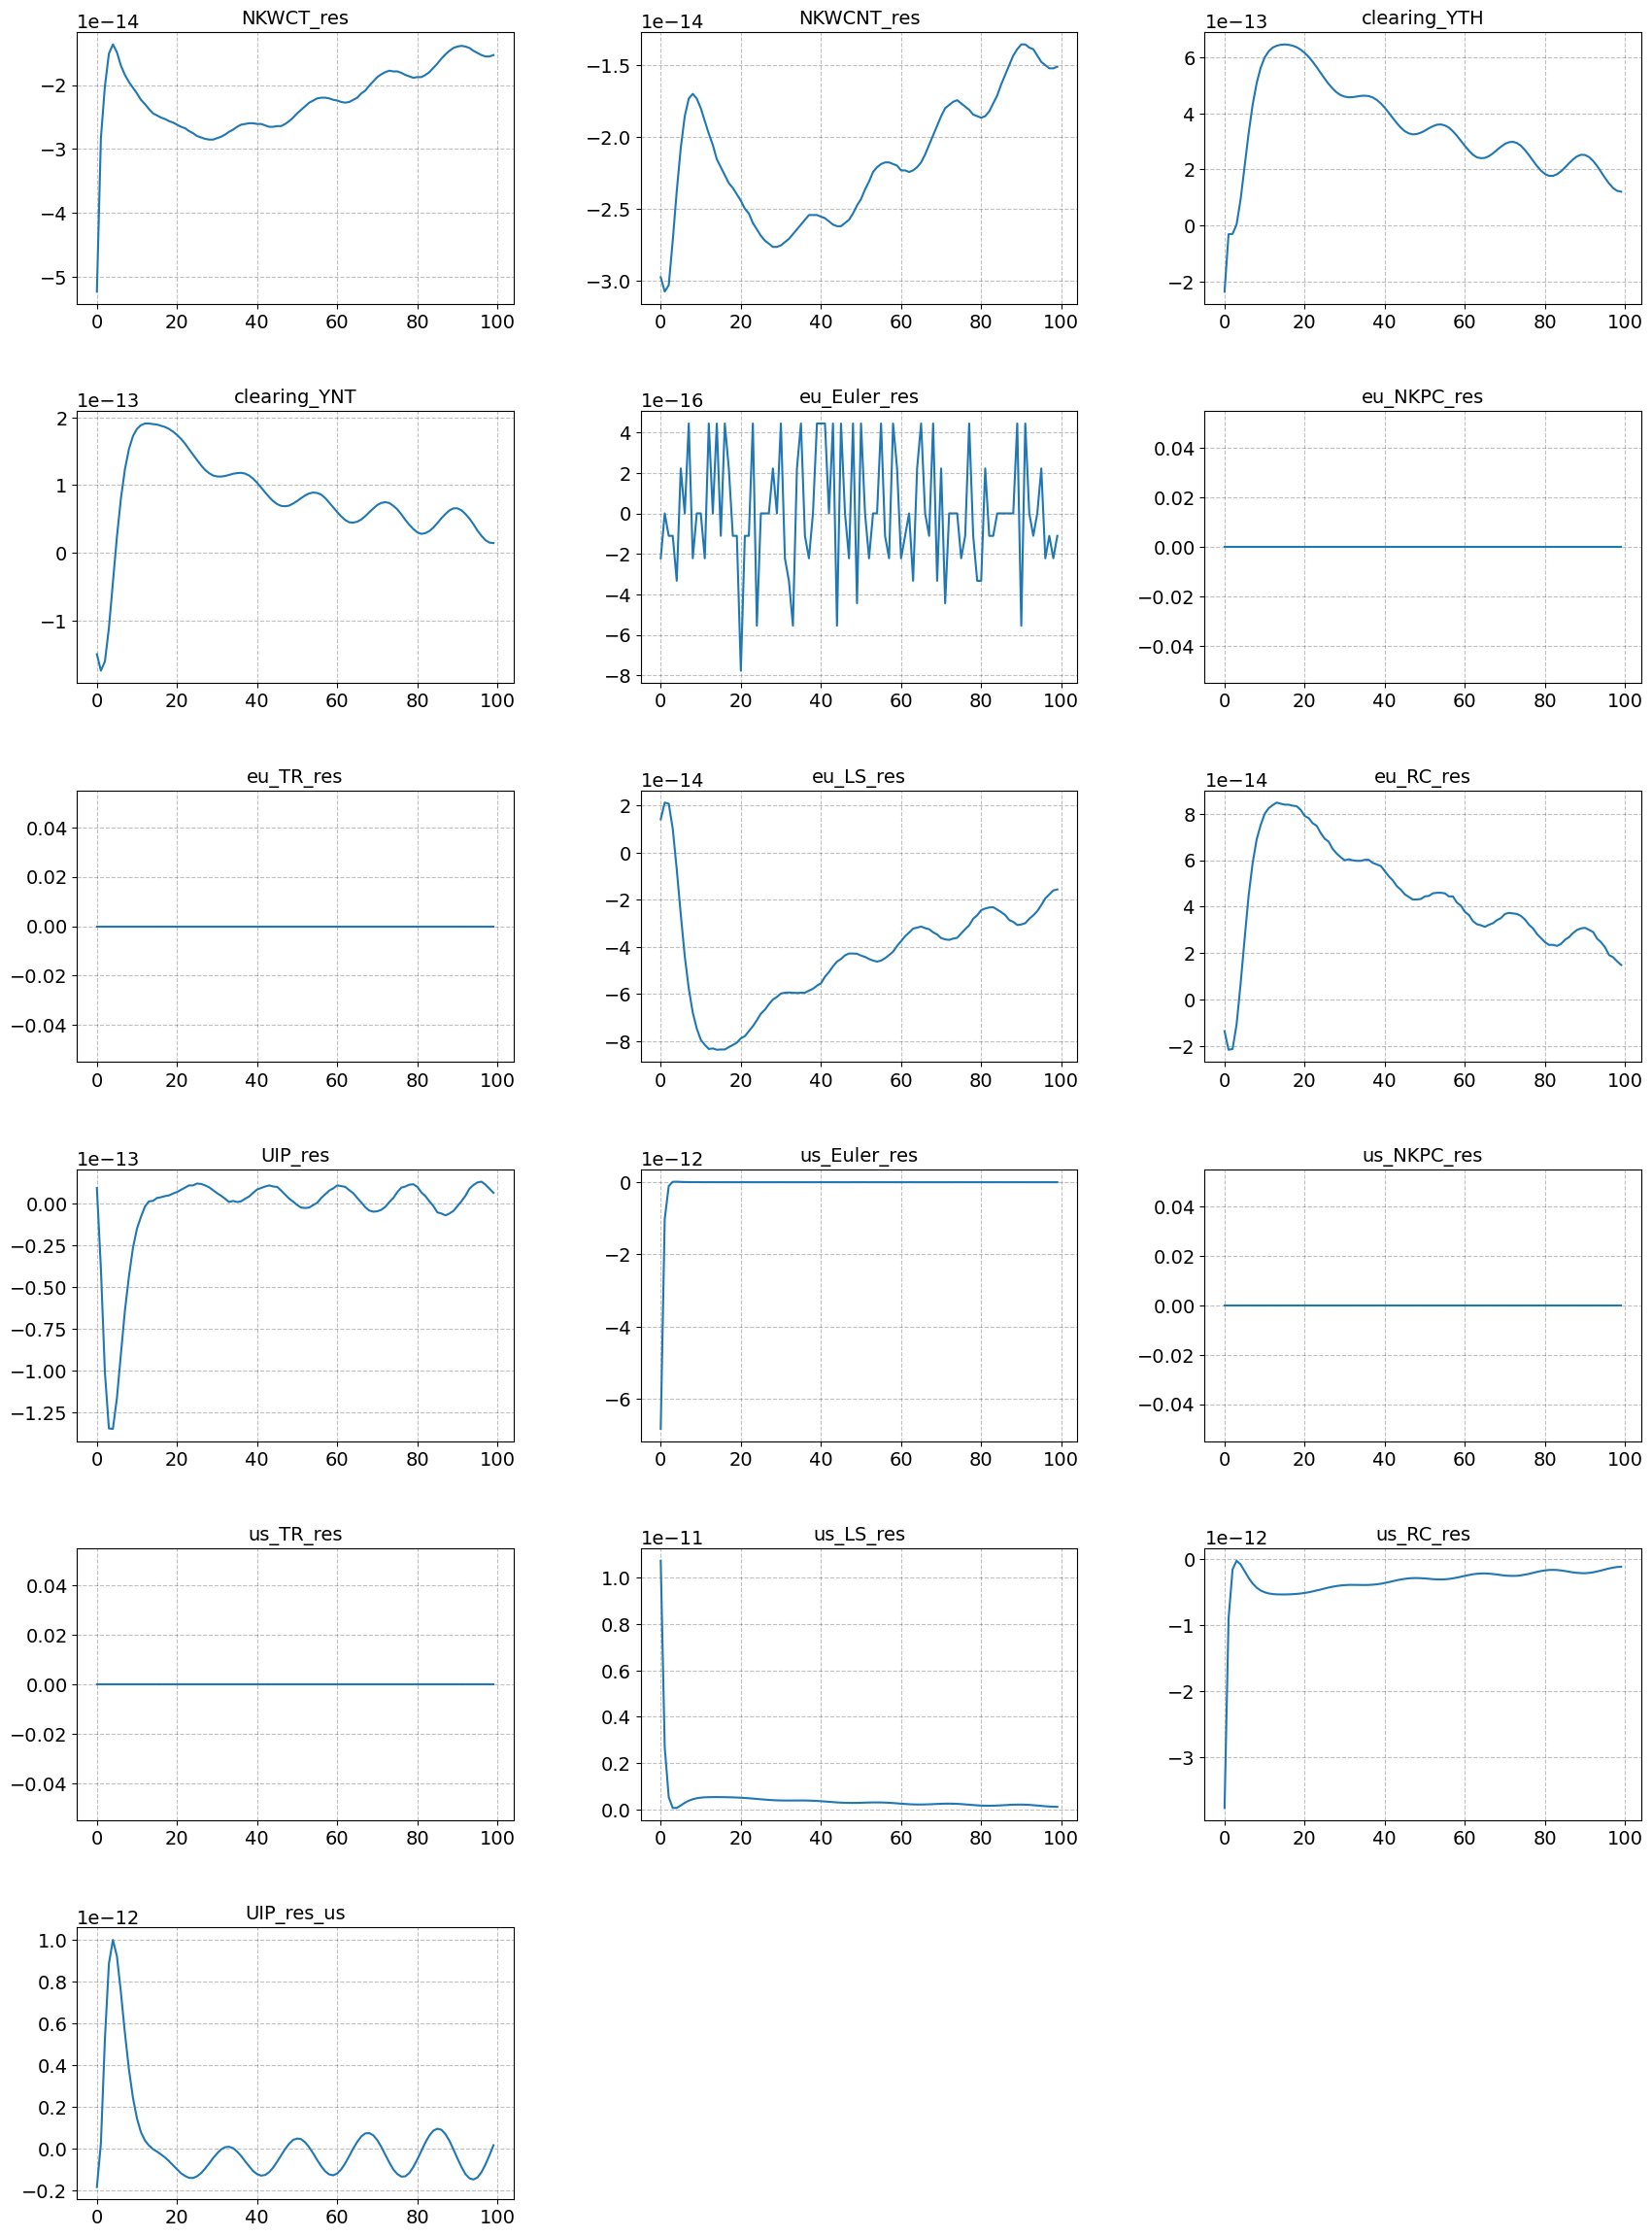

In [19]:
paths = ['M_eu_s','M_us_s','GDP','YTH','YNT','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','ra','inc_TH','inc_NT','tau','Q','E','NFA','Walras']
lvl_value=['r','NFA','Walras','i_shock', 'i_shock_eu', 'i_shock_us', 'piM_us_us', 'piM_eu_eu']
model.show_IRFs(paths,lvl_value=lvl_value,T_max=100,ncols=3, filename=os.path.join(folder_us, "i_shock_ishock_eu"))

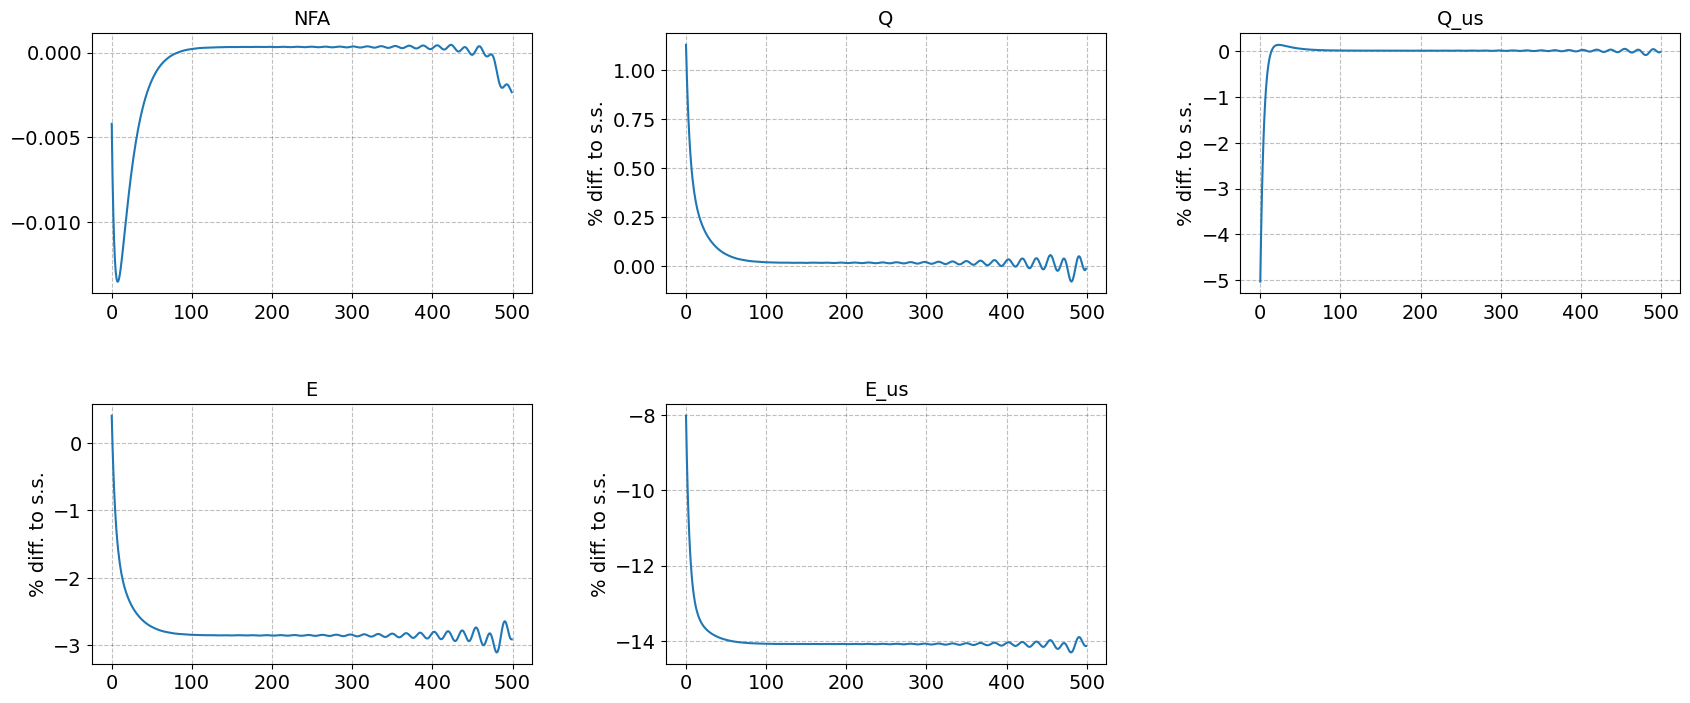

In [18]:
model.show_IRFs(['NFA','Q','Q_us','E', 'E_us'],lvl_value=lvl_value,T_max=500,ncols=3,do_shocks=False,do_targets=False)

## 5. <a id='toc5_'></a>[Response in consumption to different shocks](#toc0_)

EU i shock:

In [ ]:
M_s = model.copy()
M_s.par.jump_i_shock_eu = -0.01 # initial jump
M_s.par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

M_s.find_transition_path(shocks=['i_shock_eu'],do_print=False,do_end_check=False)

#M_s.find_IRFs(shocks=['i_shock_eu'])

Domestic Beta shock:

In [ ]:
beta = model.copy()
beta.par.jump_beta = 0.01 # initial jump
beta.par.rho_beta = 0.80 # AR(1) coefficeint

#beta.find_transition_path(shocks=['beta'],do_print=False,do_end_check=False)

beta.find_IRFs(shocks=['beta'])

Domestic G shock:

In [ ]:
G = model.copy()
G.par.jump_G = -0.025 # initial jump
G.par.rho_G = 0.80 # AR(1) coefficeint

#G.find_transition_path(shocks=['G'],do_print=False,do_end_check=False)

G.find_IRFs(shocks=['G'])

Domestic i shock:

In [ ]:
i_shock_model = model.copy()
i_shock_model.par.jump_i_shock = -0.01 # initial jump
i_shock_model.par.rho_i_shock= 0.80 # AR(1) coefficeint

#i_shock_model.find_transition_path(shocks=['i_shock'],do_print=False,do_end_check=False)

i_shock_model.find_IRFs(shocks=['i_shock'])

US i shock:

In [ ]:
i_shock_us_model = model.copy()
i_shock_us_model.par.jump_i_shock_us = -0.01 # initial jump
i_shock_us_model.par.rho_i_shock_us= 0.80 # AR(1) coefficeint

i_shock_us_model.find_transition_path(shocks=['i_shock_us'],do_print=False,do_end_check=False)

#i_shock_us_model.find_IRFs(shocks=['i_shock_us'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

varnames = ['M_eu_s','M_us_s','beta','G','i_shock', 'i_shock_eu', 'i_shock_us',
            'C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CTF_eu','CTF_us','CNT',
            'CTH_eu_s','CTH_us_s']

T_max = 50
ncols = 4
nrows = (len(varnames) + ncols - 1) // ncols

fig = plt.figure(figsize=(5*ncols, 3.5*nrows), dpi=100)

for i, varname in enumerate(varnames):
    ax = fig.add_subplot(nrows, ncols, i+1)
    ax.set_title(varname)

    x1 = i_shock_model.IRF[varname][:T_max]
    x2 = i_shock_us_model.IRF[varname][:T_max]

    if varname in ['i_shock', 'i_shock_eu', 'i_shock_us']:
        ax.plot(x1, label='i_shock')
        ax.plot(x2, label='i_shock_us')
    else:
        ss1 = getattr(i_shock_model.ss, varname)
        ss2 = getattr(i_shock_us_model.ss, varname)

        if np.isnan(ss1) or np.isnan(ss2):
            ax.plot(x1, label='i_shock')
            ax.plot(x2, label='i_shock_us')
        else:
            ax.plot(100 * x1 / ss1, label='i_shock')
            ax.plot(100 * x2 / ss2, label='i_shock_us')

    ax.axhline(0, linewidth=0.8)

    if i == 0:
        ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(folder_us, "compare_linear_IRFs.pdf"))
plt.show()

In [ ]:
models = [M_s,beta,G,i_shock_model,i_shock_us_model]
labels = ['i_shock_eu','beta','G','i_shock', 'i_shock_us']
model.compare_IRFs(models, labels,varnames=['M_eu_s','M_us_s','beta','G','i_shock', 'i_shock_eu', 'i_shock_us','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CTF_eu','CTF_us','CNT','CTH_eu_s','CTH_us_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock', 'i_shock_eu', 'i_shock_us'],T_max=50, filename=os.path.join(folder_us, "compare_shocks"))

In [ ]:
%whos
del  i_shock_model
%whos


## 6. <a id='toc6_'></a>[Decomposing consumption response](#toc0_)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

varnames = ['M_eu_s','M_us_s','beta','G','i_shock', 'i_shock_eu', 'i_shock_us',
            'C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CTF_eu','CTF_us','CNT',
            'CTH_eu_s','CTH_us_s']

T_max = 50
ncols = 4
nrows = (len(varnames) + ncols - 1) // ncols

fig = plt.figure(figsize=(5*ncols, 3.5*nrows), dpi=100)

for i, varname in enumerate(varnames):
    ax = fig.add_subplot(nrows, ncols, i+1)
    ax.set_title(varname)

    x1 = i_shock_model.IRF[varname][:T_max]
    x2 = i_shock_us_model.IRF[varname][:T_max]

    if varname in ['i_shock', 'i_shock_eu', 'i_shock_us']:
        ax.plot(x1, label='i_shock')
        ax.plot(x2, label='i_shock_us')
    else:
        ss1 = getattr(i_shock_model.ss, varname)
        ss2 = getattr(i_shock_us_model.ss, varname)

        if np.isnan(ss1) or np.isnan(ss2):
            ax.plot(x1, label='i_shock')
            ax.plot(x2, label='i_shock_us')
        else:
            ax.plot(100 * x1 / ss1, label='i_shock')
            ax.plot(100 * x2 / ss2, label='i_shock_us')

    ax.axhline(0, linewidth=0.8)

    if i == 0:
        ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(folder_us, "compare_linear_IRFs.pdf"))
plt.show()

In [ ]:
models = {'i_shock_eu': M_s, 'beta': beta, 'G': G, 'i_shock': i_shock_model}

model_titles = {
    'i_shock_eu': 'Contractionary Foreign Monetary Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock',
    'i_shock': 'Contractionary Domestic Monetary Shock'
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()


## 7. <a id='toc7_'></a>[Fixed vs floating exchange rate](#toc0_)

In [ ]:
fixed = model.copy()
fixed.par.float = False
fixed.find_ss()
fixed.compute_jacs()

Foreign demand shock:

In [ ]:
M_s_fixed = fixed.copy()
M_s_fixed.par.jump_i_shock_eu = -0.01 # initial jump
M_s_fixed.par.rho_i_shock_eu= 0.80 # AR(1) coefficeint

M_s_fixed.find_transition_path(shocks=['i_shock_eu'], do_end_check=False)

In [ ]:
i_shock_us_fixed = fixed.copy()
i_shock_us_fixed.par.jump_i_shock_us = -0.01 # initial jump
i_shock_us_fixed.par.rho_i_shock_us= 0.80 # AR(1) coefficeint

i_shock_us_fixed.find_transition_path(shocks=['i_shock_us'],do_print=False,do_end_check=False)

In [ ]:
models = [M_s,M_s_fixed,i_shock_us_model,i_shock_us_fixed]
labels = ['floating - i_eu','fixed - i_eu','floating - i_us','fixed - i_us']
model.compare_IRFs(models,labels,varnames=['M_eu_s','M_us_s', 'i_shock_eu', 'i_shock_us','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CTF_eu','CTF_us','CNT','CTH_eu_s','CTH_us_s'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock','pi', 'i_shock_eu','i', 'i_shock_us'],T_max=50, filename=os.path.join(folder_us, "fixed_float"))

Domestic beta shock:

In [ ]:
beta_fixed = fixed.copy()
beta_fixed.par.jump_beta = 0.01 # initial jump
beta_fixed.par.rho_beta = 0.80 # AR(1) coefficeint

beta_fixed.find_transition_path(shocks=['beta'])

In [ ]:
models = [beta,beta_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['beta','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

Domestic G shock:

In [ ]:
G_fixed = fixed.copy()
G_fixed.par.jump_G = -0.025 # initial jump
G_fixed.par.rho_G = 0.80 # AR(1) coefficeint

G_fixed.find_transition_path(shocks=['G'])

In [ ]:
models = [G,G_fixed]
labels = ['floating','fixed']
model.compare_IRFs(models,labels,varnames=['G','C_hh','C_TH_hh','C_NT_hh','CT','CTH','CTF','CNT','CTH_eu_s','i','E'], do_shocks=False,do_targets=False,
        abs_diff=None,lvl_value=['i_shock'],T_max=50)

## 8. <a id='toc8_'></a>[Decomposing consumption response under fixed exchange rate](#toc0_)

In [ ]:
models = {'M_s': M_s_fixed, 'beta': beta_fixed, 'G': G_fixed}

model_titles = {
    'M_s': 'Foreign Demand Shock',
    'beta': 'Domestic Beta Shock',
    'G': 'Contractionary Domestic Fiscal Shock'   
}

for model_name, model in models.items():

    T_max = 50

    fig, (ax_C_NT, ax_C_TH) = plt.subplots(1, 2, figsize=(16, 4), dpi=100)
    fig.suptitle(f'{model_titles[model_name]}', fontsize=16)

    ax_C_NT.set_title('Consumption non-tradeable sector HH, $C_{NT}^{hh}$', fontsize=12)
    ax_C_TH.set_title('Consumption tradeable sector HH, $C_{TH}^{hh}$', fontsize=12)

    i_color = 0

    for use_inputs in [[x] for x in model.inputs_hh]:

        # a. compute
        path_alt = model.decompose_hh_path(do_print=False, use_inputs=use_inputs)

        # b. plot
        if use_inputs is None:
            label = 'No inputs'
            ls = '--'
            color = 'black'
        elif use_inputs == 'all':
            label = 'All inputs'
            ls = '-'
            color = 'black'
        else:
            label = f'Only effect from {use_inputs[0]}'
            ls = '-'
            color = f'C{i_color}' # use color index directly
            i_color += 1

        ax_C_NT.plot((path_alt.C_NT_hh[:T_max] / ss.C_NT_hh - 1) * 100, ls=ls, color=color, label=label)
        ax_C_TH.plot((path_alt.C_TH_hh[:T_max] / ss.C_TH_hh - 1) * 100, ls=ls, color=color, label=label)

    for ax in [ax_C_NT, ax_C_TH]:
        ax.set_ylabel('% diff to s.s.')
        lgd = ax_C_TH.legend(frameon=True, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()
